# Elliptical Channel Augmentation — Implementation

We lift the flow into a higher-dimensional augmented space by giving each of C channels its own elliptical path from source to target. In the augmented space, trajectories that would cross in the original 2D space are separated, making the velocity field easier to learn.

Each channel i follows:
$$x_i(\tau) = m - v\cos(\tau\pi) + w_i\sin(\tau\pi), \quad \tau \in [0,1]$$
where $m=(A+B)/2$, $v=(B-A)/2$, and $w_i$ is $r_i$ projected perpendicular to $\hat{v}$, scaled by $f\|v\|$. All channels share the same aspect ratio $f$; the separation comes from the different frozen directions $r_i$.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

N   = 100
std = 0.35

# Same crossing cluster layout as in motivation.ipynb
A = rng.normal([-2,  2], std, (N, 2))  # top-left   → source 1
B = rng.normal([ 2,  2], std, (N, 2))  # top-right  → source 2
C = rng.normal([ 2, -2], std, (N, 2))  # bottom-right → target of A
D = rng.normal([-2, -2], std, (N, 2))  # bottom-left  → target of B

In [2]:
N_CH  = 4    # number of channels
D_DIM = 2    # data dimensionality
F     = 0.8  # ellipse aspect ratio (same for all channels)

# Frozen random vectors — fixed once, never updated
torch.manual_seed(99)
R = torch.randn(N_CH, D_DIM)
R = R / R.norm(dim=-1, keepdim=True)  # unit vectors
print('Frozen R:\n', R.numpy())

Frozen R:
 [[ 0.4622445  -0.88675255]
 [-0.753798   -0.6571063 ]
 [ 0.75558853 -0.6550466 ]
 [-0.9812324  -0.19282886]]


## Visualising the elliptical paths

For a single source-target pair we draw all C arcs to confirm they start and end at the same point but deviate differently in between.

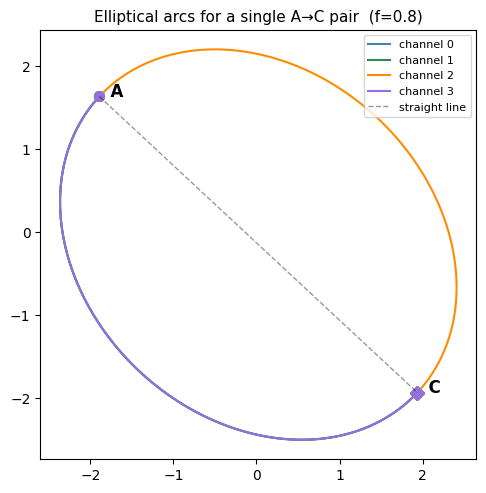

In [3]:
def elliptical_arc(a, b, r, f, n_pts=200):
    """Return (n_pts, 2) arc for one channel given numpy a, b."""
    a, b, r = torch.tensor(a, dtype=torch.float32), torch.tensor(b, dtype=torch.float32), r.clone()
    m = (a + b) / 2
    v = (b - a) / 2
    v_norm = v.norm().clamp(min=1e-8)
    v_hat  = v / v_norm
    proj   = (r * v_hat).sum()
    w      = r - proj * v_hat
    w      = w / w.norm().clamp(min=1e-8) * f * v_norm
    tau    = torch.linspace(0, 1, n_pts)
    t      = tau * torch.pi
    pts    = m - v * torch.cos(t)[:, None] + w * torch.sin(t)[:, None]
    return pts.numpy()

# Use the first pair: A[0] -> C[0]
a0, c0 = A[0], C[0]
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(5, 5))
for i in range(N_CH):
    arc = elliptical_arc(a0, c0, R[i], F)
    ax.plot(arc[:, 0], arc[:, 1], color=colors[i], lw=1.5, label=f'channel {i}')
    ax.plot(*arc[0],   'o', color=colors[i], ms=7)
    ax.plot(*arc[-1],  'D', color=colors[i], ms=7)

ax.plot([a0[0], c0[0]], [a0[1], c0[1]], 'k--', lw=1, alpha=0.4, label='straight line')
ax.text(*a0, '  A', fontsize=12, fontweight='bold')
ax.text(*c0, '  C', fontsize=12, fontweight='bold')
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right')
ax.set_title(f'Elliptical arcs for a single A→C pair  (f={F})', fontsize=11)
plt.tight_layout()
plt.savefig('elliptical_arcs.png', dpi=150)
plt.show()

## Path construction for training

`make_elliptical_paths` takes a batch of source-target pairs and a batch of normalized times $\tau \in [0,1]$, and returns the augmented state (all C channel positions concatenated) and the corresponding velocity $dx/d\tau$.

In [4]:
def make_elliptical_paths(x0, x1, tau, R, f):
    """
    x0, x1 : (N, d)
    tau     : (N,)  in [0, 1]  (t = tau * pi)
    R       : (n_ch, d)  frozen random directions
    f       : scalar aspect ratio (same for all channels)

    Returns
    -------
    xt : (N, n_ch * d)   augmented state
    ut : (N, n_ch * d)   dx / dtau  (target velocity for the model)
    """
    n_ch = R.shape[0]
    t    = tau * torch.pi

    m      = (x0 + x1) / 2
    v      = (x1 - x0) / 2
    v_norm = v.norm(dim=-1, keepdim=True).clamp(min=1e-8)
    v_hat  = v / v_norm

    cos_t = torch.cos(t).unsqueeze(-1)
    sin_t = torch.sin(t).unsqueeze(-1)

    xt_list, ut_list = [], []
    for i in range(n_ch):
        r    = R[i]
        proj = (r * v_hat).sum(-1, keepdim=True)
        w    = r - proj * v_hat
        w    = w / w.norm(dim=-1, keepdim=True).clamp(min=1e-8) * f * v_norm

        x_i = m - v * cos_t + w * sin_t
        u_i = torch.pi * (v * sin_t + w * cos_t)

        xt_list.append(x_i)
        ut_list.append(u_i)

    return torch.cat(xt_list, dim=-1), torch.cat(ut_list, dim=-1)

## Model and training

The MLP takes the full augmented state (all C channels concatenated) plus $\tau$ as input and predicts the full augmented velocity.

In [5]:
class AugmentedVelocityMLP(nn.Module):
    def __init__(self, n_ch, d, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_ch * d + 1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),        nn.Tanh(),
            nn.Linear(hidden, hidden),        nn.Tanh(),
            nn.Linear(hidden, n_ch * d),
        )

    def forward(self, x, tau):
        # x: (N, n_ch*d),  tau: (N,)
        return self.net(torch.cat([x, tau.unsqueeze(-1)], dim=-1))

136,200 parameters


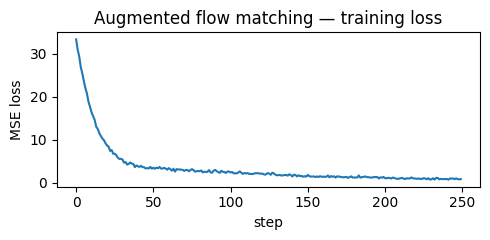

In [6]:
x0_all = torch.tensor(np.concatenate([A, B]), dtype=torch.float32)  # (2N, 2)
x1_all = torch.tensor(np.concatenate([C, D]), dtype=torch.float32)  # (2N, 2)

torch.manual_seed(0)
model_aug = AugmentedVelocityMLP(N_CH, D_DIM)
opt       = torch.optim.Adam(model_aug.parameters(), lr=1e-3)
print(f'{sum(p.numel() for p in model_aug.parameters()):,} parameters')

N_STEPS    = 250
losses_aug = []

for _ in range(N_STEPS):
    tau = torch.rand(x0_all.shape[0])                      # tau ~ Uniform[0, 1]
    xt, ut = make_elliptical_paths(x0_all, x1_all, tau, R, F)
    loss = ((model_aug(xt, tau) - ut) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    losses_aug.append(loss.item())

plt.figure(figsize=(5, 2.5))
plt.plot(losses_aug)
plt.xlabel('step'); plt.ylabel('MSE loss')
plt.title('Augmented flow matching — training loss')
plt.tight_layout()
plt.show()

## Generation

Start from C copies of each source point (all channels identical at $\tau=0$). Integrate forward to $\tau=1$. The output is the mean of the C final channel positions.

In [7]:
@torch.no_grad()
def euler_integrate_aug(model, x0, n_ch, n_steps=200):
    """
    x0      : (N, d)  source points
    Returns final positions (N, d) and full trajectory list (n_steps+1, N, n_ch, d)
    """
    # Duplicate: each channel starts at x0
    x = x0.repeat(1, n_ch)                                 # (N, n_ch*d)
    dt = 1.0 / n_steps
    traj = [x.numpy().copy()]

    for i in range(n_steps):
        tau = torch.full((x.shape[0],), i * dt)
        x   = x + model(x, tau) * dt
        traj.append(x.numpy().copy())

    traj  = np.stack(traj)                                 # (n_steps+1, N, n_ch*d)
    # Reshape to (n_steps+1, N, n_ch, d) and average over channels
    d     = x0.shape[1]
    traj3 = traj.reshape(traj.shape[0], traj.shape[1], n_ch, d)
    x_out = torch.tensor(traj[-1]).reshape(-1, n_ch, d).mean(dim=1)  # (N, d)
    return x_out, traj3


x0_src = torch.tensor(np.concatenate([A, B]), dtype=torch.float32)
x_final, trajs = euler_integrate_aug(model_aug, x0_src, N_CH)

x_final_np = x_final.numpy()
trajs_A = trajs[:, :N, :, :]   # (steps, N, n_ch, 2) — started from A
trajs_B = trajs[:, N:, :, :]

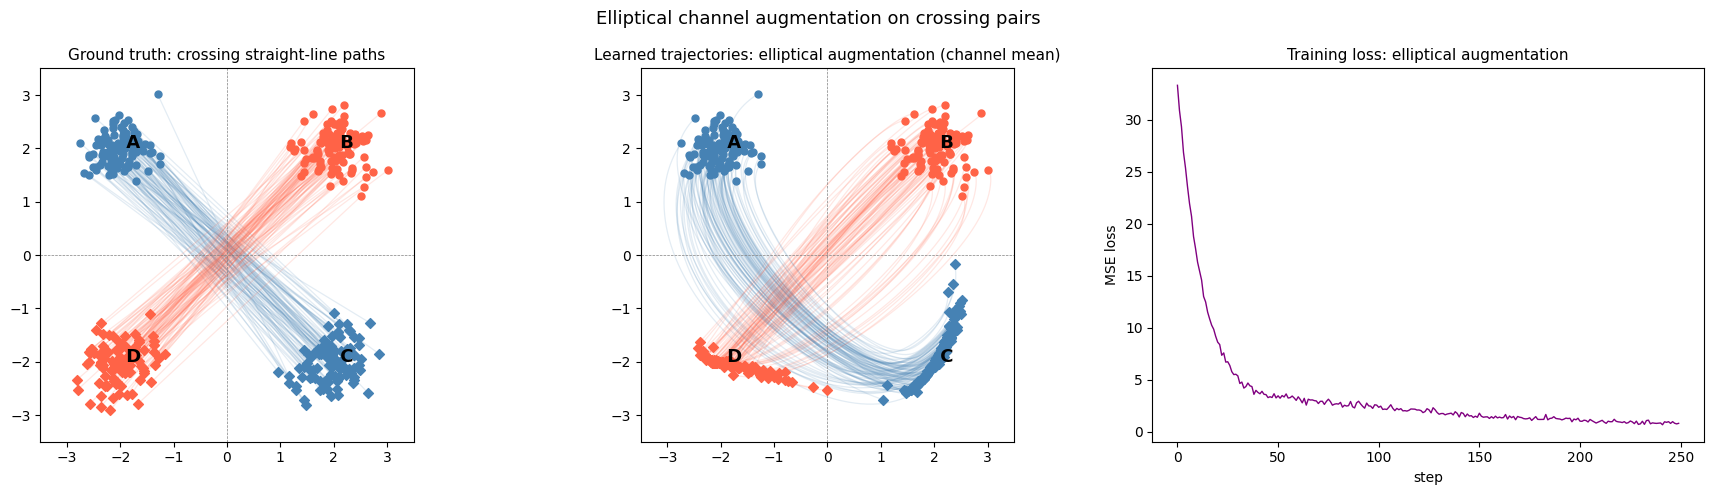

A->C endpoint error: 0.693
B->D endpoint error: 0.640


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Ground truth ---
ax = axes[0]
for a, c in zip(A, C):
    ax.plot([a[0], c[0]], [a[1], c[1]], color='steelblue', alpha=0.15, lw=0.9)
for b, d in zip(B, D):
    ax.plot([b[0], d[0]], [b[1], d[1]], color='tomato', alpha=0.15, lw=0.9)
ax.scatter(*A.T, color='steelblue', s=25, zorder=3)
ax.scatter(*C.T, color='steelblue', s=25, zorder=3, marker='D')
ax.scatter(*B.T, color='tomato',    s=25, zorder=3)
ax.scatter(*D.T, color='tomato',    s=25, zorder=3, marker='D')
ax.set_title('Ground truth: crossing straight-line paths', fontsize=11)

# --- Learned trajectories (channel mean shown in 2D) ---
ax = axes[1]
for i in range(N):
    # Show mean-channel trajectory in 2D
    path_a = trajs_A[:, i, :, :].mean(axis=1)  # (steps, 2)
    path_b = trajs_B[:, i, :, :].mean(axis=1)
    ax.plot(path_a[:, 0], path_a[:, 1], color='steelblue', alpha=0.15, lw=0.9)
    ax.plot(path_b[:, 0], path_b[:, 1], color='tomato',    alpha=0.15, lw=0.9)
ax.scatter(*A.T,              color='steelblue', s=25, zorder=3)
ax.scatter(*x_final_np[:N].T, color='steelblue', s=25, zorder=3, marker='D')
ax.scatter(*B.T,              color='tomato',    s=25, zorder=3)
ax.scatter(*x_final_np[N:].T, color='tomato',    s=25, zorder=3, marker='D')
ax.set_title('Learned trajectories: elliptical augmentation (channel mean)', fontsize=11)

for ax in axes[:2]:
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5); ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    for name, center in [('A', [-2,2]),('B',[2,2]),('C',[2,-2]),('D',[-2,-2])]:
        ax.text(center[0], center[1], f' {name} ', fontsize=13, fontweight='bold', zorder=5)

# --- Loss ---
ax = axes[2]
ax.plot(losses_aug, color='purple', lw=1)
ax.set_xlabel('step'); ax.set_ylabel('MSE loss')
ax.set_title('Training loss: elliptical augmentation', fontsize=11)

plt.suptitle('Elliptical channel augmentation on crossing pairs', fontsize=13)
plt.tight_layout()
plt.savefig('elliptical_flow_results.png', dpi=150)
plt.show()

print(f'A->C endpoint error: {np.linalg.norm(x_final_np[:N] - C, axis=1).mean():.3f}')
print(f'B->D endpoint error: {np.linalg.norm(x_final_np[N:] - D, axis=1).mean():.3f}')